# 11-05-2026

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# setting drawing
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)



In [13]:
# download and understand the dataset
# File -> Data
df = pd.read_csv('../pandas2/FINAL_DATASET.csv')

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6557 entries, 0 to 6556
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   image_id              6557 non-null   int64  
 1   image_url             6557 non-null   str    
 2   label                 6557 non-null   str    
 3   label_numeric         6557 non-null   int64  
 4   category              6557 non-null   str    
 5   gender                6557 non-null   str    
 6   age_group             6557 non-null   str    
 7   source                6557 non-null   str    
 8   fake_method           3767 non-null   str    
 9   image_quality         6557 non-null   str    
 10  resolution            6557 non-null   str    
 11  confidence_score      6557 non-null   float64
 12  detection_difficulty  6557 non-null   str    
 13  dataset_split         6557 non-null   str    
 14  date_collected        6557 non-null   str    
 15  version               6557 non-n

In [15]:
df.describe()

,image_id,label_numeric,confidence_score,year
count,6557.00000,6557.000000,6557.000000,6557.0
mean,3279.00000,0.425499,0.903741,2026.0
std,1892.98719,0.494456,0.049982,0.0
min,1.00000,0.000000,0.800000,2026.0
25%,1640.00000,0.000000,0.860000,2026.0
50%,3279.00000,0.000000,0.910000,2026.0
75%,4918.00000,1.000000,0.950000,2026.0
max,6557.00000,1.000000,0.990000,2026.0


In [16]:
df.columns

Index(['image_id', 'image_url', 'label', 'label_numeric', 'category', 'gender',
       'age_group', 'source', 'fake_method', 'image_quality', 'resolution',
       'confidence_score', 'detection_difficulty', 'dataset_split',
       'date_collected', 'version', 'year'],
      dtype='str')

In [17]:
df["label"].unique()

<StringArray>
['REAL', 'FAKE']
Length: 2, dtype: str

In [18]:
df["gender"].unique()

<StringArray>
['Female', 'Male', 'Unknown']
Length: 3, dtype: str

In [19]:
df["age_group"].unique()

<StringArray>
['18-25', '50+', '36-50', '26-35']
Length: 4, dtype: str

In [20]:
df["image_quality"].unique()

<StringArray>
['High', 'Medium']
Length: 2, dtype: str

In [21]:
df["label"].value_counts()

label
FAKE    3767
REAL    2790
Name: count, dtype: int64

In [22]:
df["gender"].value_counts()

gender
Unknown    4507
Female     1033
Male       1017
Name: count, dtype: int64

# Step 1: Does dataset contain the same count of fake and real images?

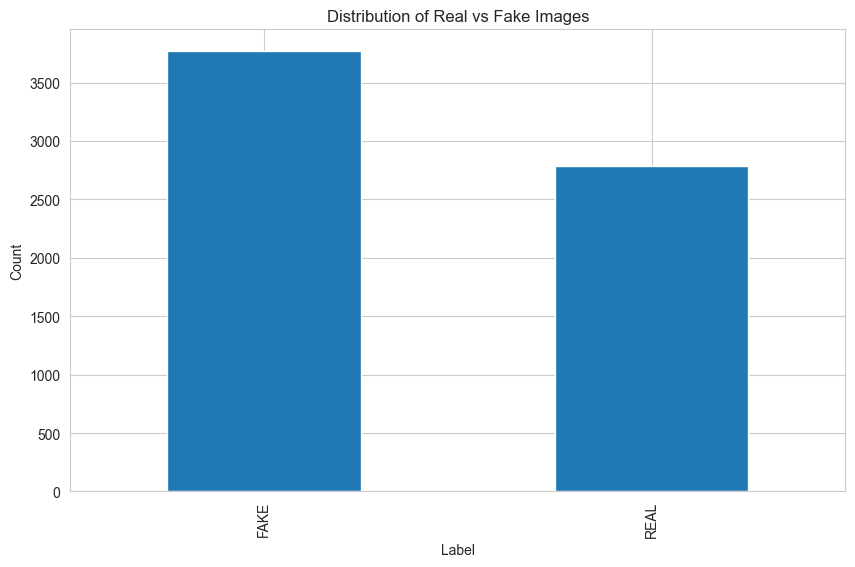

In [23]:
# Line Plot(Linje)
# create the drawing
df["label"].value_counts().plot(kind="bar")

plt.title("Distribution of Real vs Fake Images")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()


#### The dataset contains more fake images than real images. 
#### This may affect model training and evaluation.

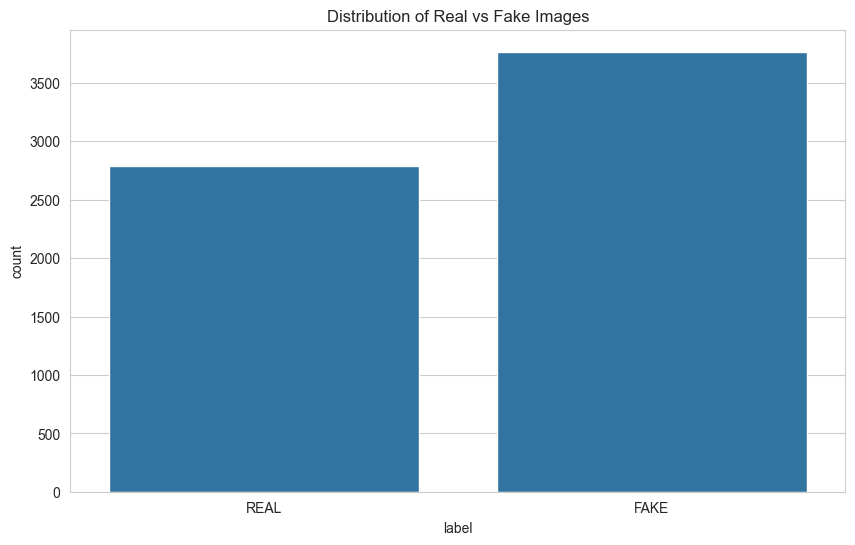

In [ ]:
# The same draw with seaborn
sns.countplot(data=df, x="label")

plt.title("Distribution of Real vs Fake Images")

plt.show()



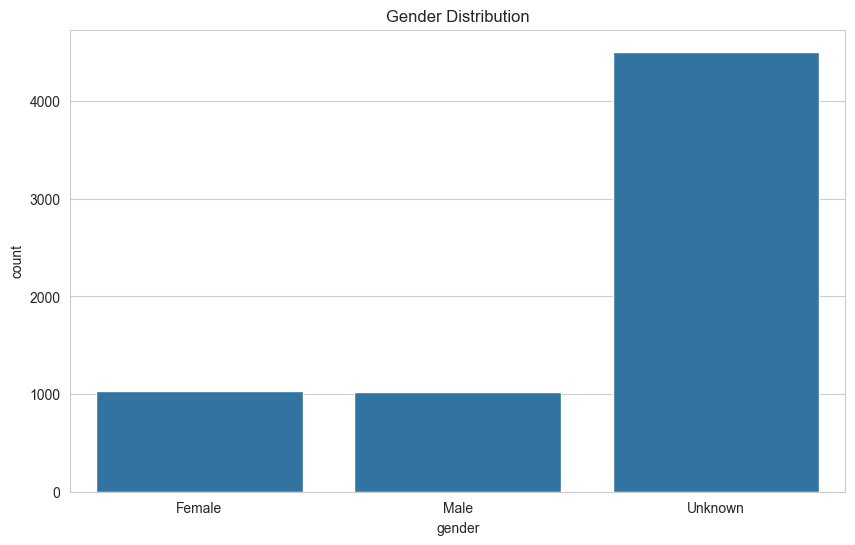

In [25]:
# how is gender divided inside the images
sns.countplot(data=df, x="gender")
plt.title("Gender Distribution")
plt.show() 

#### Most images have unknown gender labels, which may reduce the reliability of gender based analysis

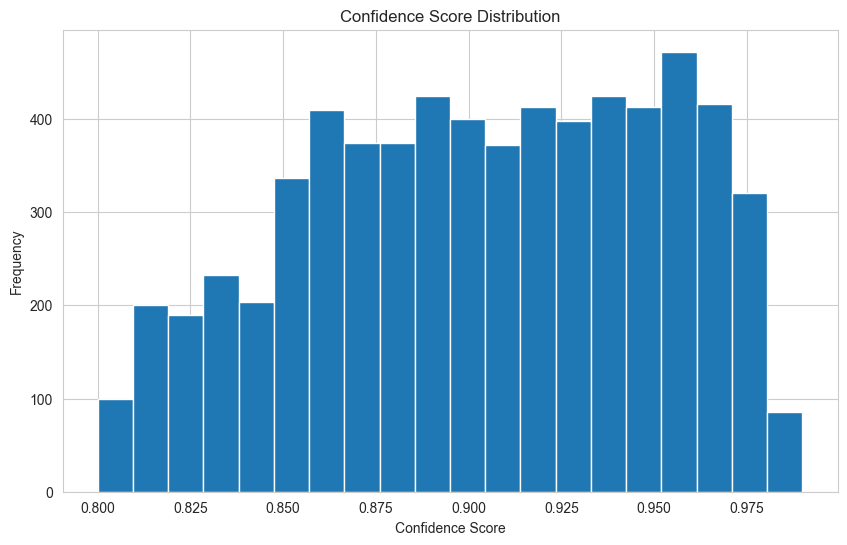

In [26]:
# The first history
# How are the scores confidence distributed?
plt.hist(df["confidence_score"], bins=20)

plt.title("Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")

plt.show()

#### Most of the result are between 0.85 -> 0.97
#### Most confidence scores are relatively high, ranging mainly between 0.85 and 0.97.
- This suggests that the detection system is generally confident in its predictions.
- Very low confidence scores are rare, which may indicate a clean or less challenging dataset.

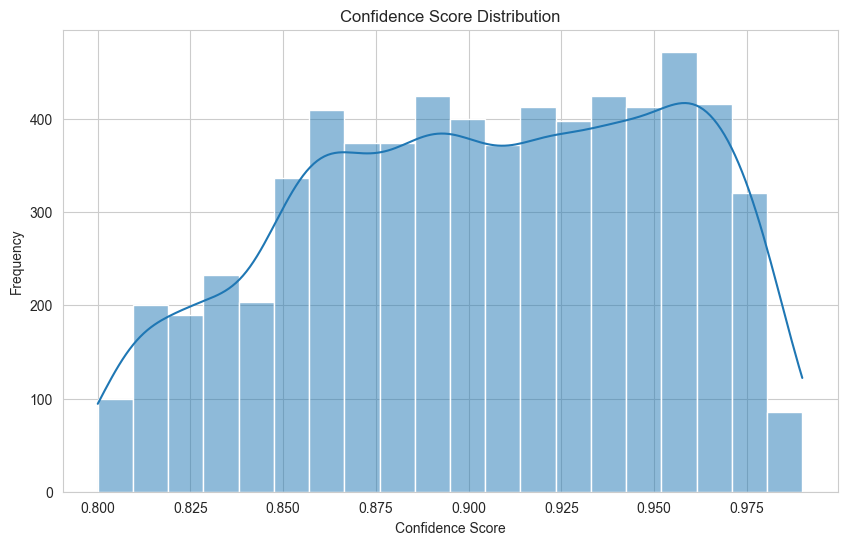

In [28]:
# Cleaner drawing
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="confidence_score",
    bins=20,
    kde=True
)

plt.title("Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")

plt.show()

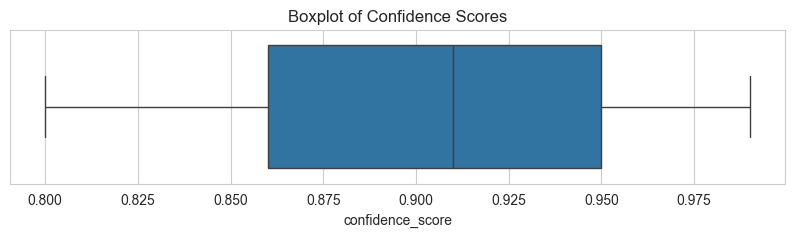

In [31]:
# Boxplot in order to know the (median, spread, outliers)
plt.figure(figsize=(10,2))
sns.boxplot(x=df["confidence_score"])
plt.title("Boxplot of Confidence Scores")

plt.show()

#### The boxplot shows that:
- Most confidence scores are concentrated in the higher range.
- The median confidence score is around 0.91, indicating generally strong prediction confidence.
- There appear to be few or no significant outliers.

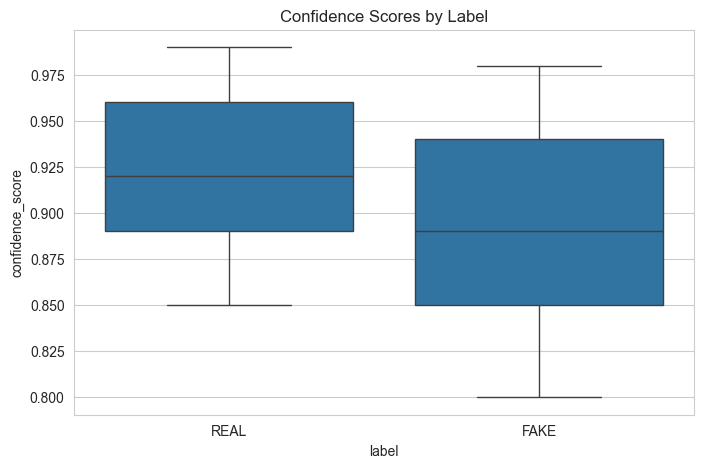

In [33]:
# Are confidence scores different between real and fake images? 
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="confidence_score"
)

plt.title("Confidence Scores by Label")

plt.show()

### REAL and FAKE Boxplot:

- Both categories show generally high confidence values, ranging roughly from 0.80 to 0.97. 
- The REAL label has a slightly higher median confidence score than the FAKE label, indicating that the model tends to be more confident when predicting REAL samples. 
- The spread (IQR) for both labels is similar, though FAKE shows a slightly wider distribution, suggesting more variability in the model’s confidence. 
- Outliers appear in both categories, which may represent difficult or ambiguous cases.

<Axes: xlabel='confidence_score', ylabel='Count'>

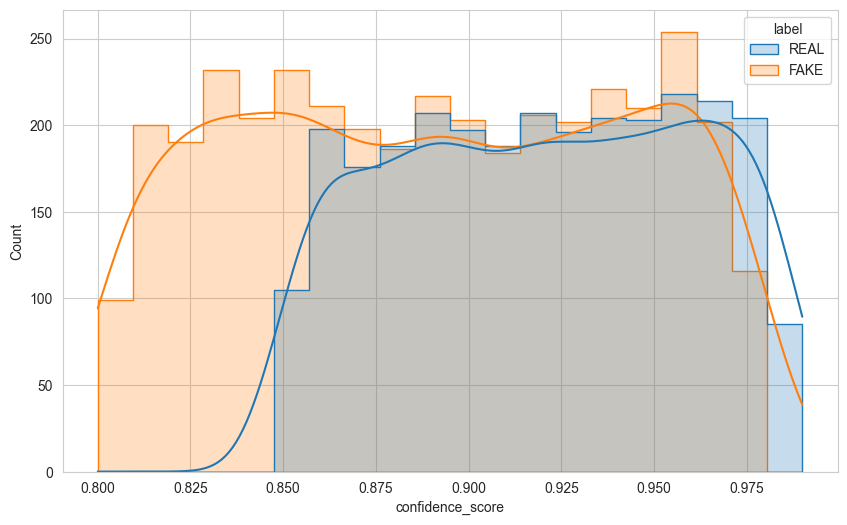

In [35]:
sns.histplot(
    data=df,
    x="confidence_score",
    hue="label",
    kde=True,
    element="step"
)

<Axes: xlabel='label', ylabel='confidence_score'>

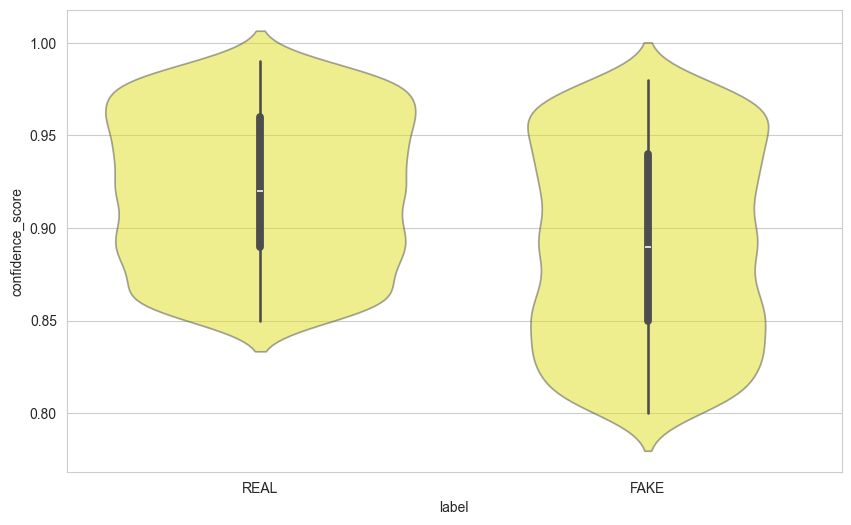

In [44]:
sns.violinplot( data=df, x="label", y="confidence_score", color="yellow", alpha=0.5)

# Firstly: Histogram (KDE, matplotlib, seaborn)


#### - Does the model give a higher confidence for a specific category?
#### - Is the distribution model stability OR model uncertainty?
#### - Is the a big overlap between REAL and FAKE or not?

C:\Users\Fatimalmurtadha\AppData\Local\Temp\ipykernel_15616\138973717.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(


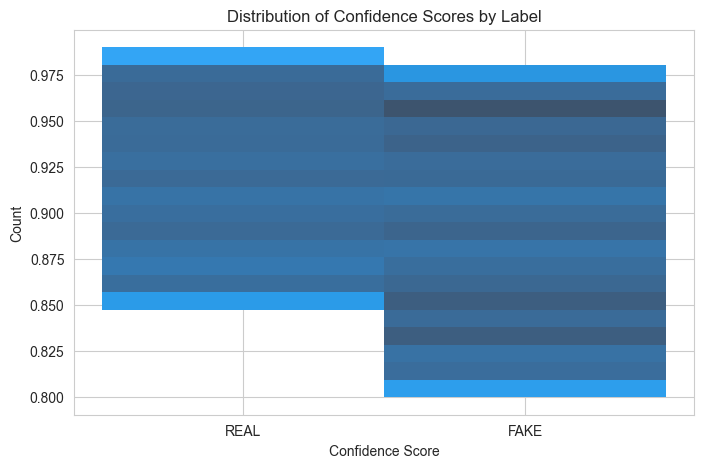

In [60]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="label",
    y="confidence_score",
    kde=True,
    element="step",
    palette="Set2"
)
plt.title("Distribution of Confidence Scores by Label")
plt.xlabel("Confidence Score")
plt.ylabel("Count")

plt.show()


### The histogram with KDE curves shows how confidence scores are distributed for REAL and FAKE labels. 
- Both classes have high confidence values overall, but the REAL label appears slightly more concentrated at higher scores. 
- The overlap between the two distributions indicates that the model behaves similarly for both classes, though REAL predictions may be slightly more consistent. 
- This visualization helps evaluate model stability and detect potential bias.

# Secondly: Scatter Plot (how confidence scores are distributed across the FAKE and REAL label)
- Dose the model give a higher confidence score for the REAL label or the FAKE label?
- Does the shorter texts cause unstable confidence scores?  
- Is there a clear monster that can be used to improve preprocessing?

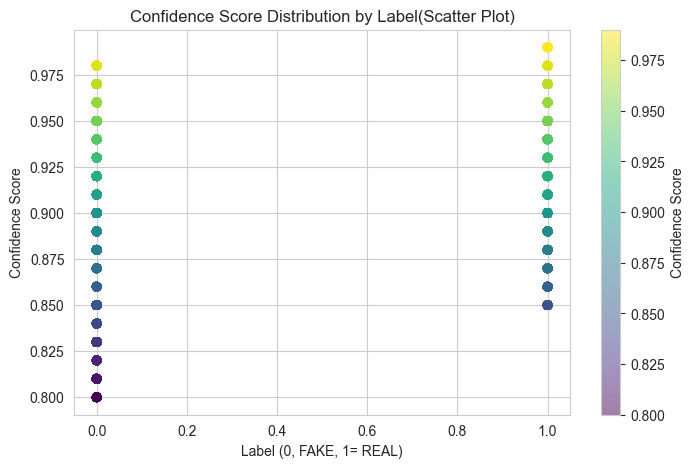

In [49]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["label_numeric"],
    df["confidence_score"],
    alpha=0.5,
    c=df["confidence_score"],
    cmap="viridis"
)

plt.title("Confidence Score Distribution by Label(Scatter Plot)")
plt.xlabel("Label (0, FAKE, 1= REAL)")
plt.ylabel("Confidence Score")

plt.colorbar(label="Confidence Score")
plt.show()

### The scatter plot shows how confidence scores are distributed across the two labels (0 = FAKE, 1 = REAL). Each point represents one image.
- If the REAL label (1) shows higher or more concentrated confidence values, it means the model is more confident when predicting REAL samples. 
- If both labels overlap heavily, the model behaves similarly for both classes. Outliers may indicate difficult or ambiguous cases. 
- This visualization helps evaluate class-specific confidence patterns and potential bias.

# Thirdly: Correlation Heatmap (seaborn)
- Dose the model give a higher confidence score for any of the categories?
- Is there any correlation between the image type and confidence score? 

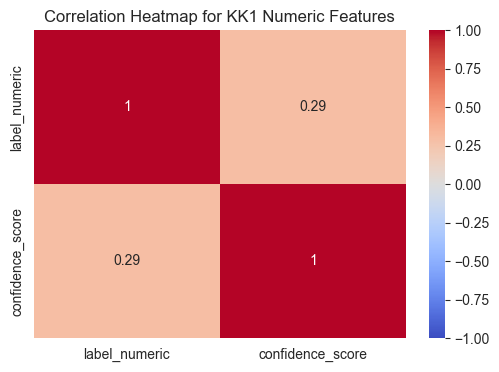

In [50]:
plt.figure(figsize=(6,4))

numeric_df = df[["label_numeric", "confidence_score"]]

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap for KK1 Numeric Features")
plt.show()

#### The heatmap displays the correlation between the numeric features in the KK1 dataset: label_numeric and confidence_score
- This visualization helps determine whether the model’s confidence is systematically higher for REAL (1) or FAKE (0) images.
- A positive correlation indicates higher confidence for REAL samples, while a negative correlation indicates higher confidence for FAKE samples.
- A correlation close to zero suggests that the model’s confidence is similar across both classes. This heatmap is useful for detecting potential bias or class-specific behavior in the model.

# Bar Chart: Distribution of REAL vs FAKE images:
- Is the dataset balanced?
- Does the model need class balancing?
- Is the accuracy going to be  misleading because of the imbalance?
- Should we use accuracy instead of confidence score?

C:\Users\Fatimalmurtadha\AppData\Local\Temp\ipykernel_15616\3716410631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


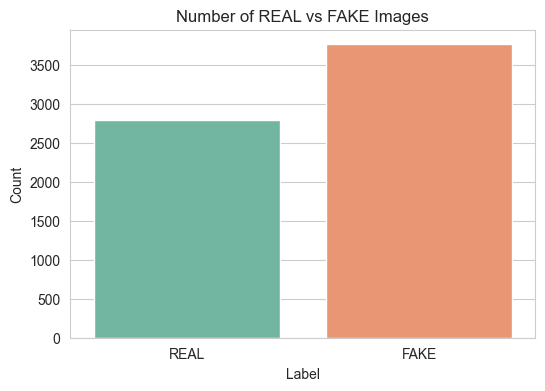

In [53]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df, 
    x="label",
    palette="Set2"
)
plt.title("Number of REAL vs FAKE Images")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

#### The bar chart shows the number of images in each class: REAL and FAKE. 
- The dataset is imbalanced, with significantly more FAKE images than REAL ones.
- This imbalance may influence model performance, potentially causing the model to favor the FAKE class.
- Understanding class distribution is essential before training any classifier, as it affects accuracy, bias, and evaluation metrics.

# Line Plot: Confidence Score Trend Across Dataset
- How much is the dataset balanced?

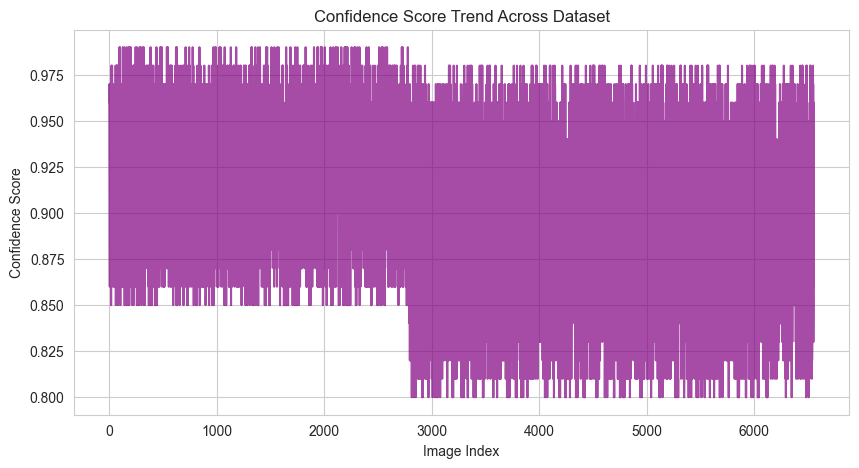

In [54]:
plt.figure(figsize=(10,5))

plt.plot(
    df.index,
    df["confidence_score"],
    color="purple",
    alpha=0.7
)

plt.title("Confidence Score Trend Across Dataset")
plt.xlabel("Image Index")
plt.ylabel("Confidence Score")

plt.show()

#### The line plot shows how the model’s confidence score changes across the dataset. 
- Each point on the line represents one image, ordered by index. A stable line indicates consistent model confidence, while strong fluctuations suggest uncertainty or difficult samples.
- Sudden drops may highlight problematic or ambiguous images. This visualization helps evaluate the model’s stability and detect potential weaknesses.


# Pairplot (seaborn)

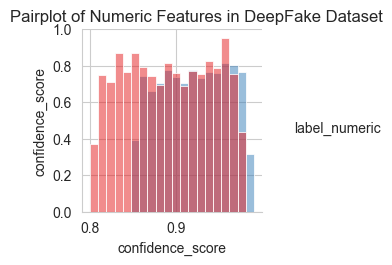

In [58]:
sns.pairplot(
    df[["label_numeric", "confidence_score"]],
    hue="label_numeric",
    palette="Set1",
    diag_kind="hist"
)
plt.suptitle("Pairplot of Numeric Features in DeepFake Dataset", y=1.02)
plt.show()

#### The pairplot visualizes the relationships between the numeric features in the KK1 dataset.
- Since the dataset contains only two meaningful numeric variables—labelnumeric and confidencescore—the pairplot shows a histogram for each variable and a scatter plot comparing them.
- The scatter plot reveals how confidence scores differ between REAL (1) and FAKE (0) images.
- If the points for one label cluster at higher confidence values, it indicates that the model is more confident for that class. - This visualization provides a compact overview of numeric feature interactions and potential class-specific patterns.